# **Churn Prediction Using XGBoost**

# All Imports Here

In [197]:
import os
gbl_pth = 'd:\\GitHub\\Falconstack_SaaS_Growth_Retention'
os.chdir(gbl_pth)

In [198]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from xgboost import XGBClassifier

# Features Selected Based On Prior Analysis

- Is Trial
- Referral Source
- Industry
- Plan Tier
- Usage Count
- Usage Duration
- Error Count
- Upgrade Flag
- Downgrade Flag
- Support Tickets Counts

# Target

- Churn Flag

# Import Datasets

In [199]:
file_pth = '\\data\\cleaned'

accounts_df = pd.read_csv(f'{gbl_pth}\\{file_pth}\\accounts_cleaned.csv') # is_trial, churn_flag, referral_source, industry, plan_tier
feature_df = pd.read_csv(f'{gbl_pth}\\{file_pth}\\feature_usage_cleaned.csv') # usage_count, usage_duration_secs, error_count
subscriptions_df = pd.read_csv(f'{gbl_pth}\\{file_pth}\\subscriptions_cleaned.csv') # upgrade_flag, downgrade_flag
support_df = pd.read_csv(f'{gbl_pth}\\{file_pth}\\support_tickets_cleaned.csv') # support_tickets_counts

# Merge Datasets to Create Required Final DataFrame

In [200]:
df = pd.merge(
    accounts_df[['account_id', 'is_trial', 'churn_flag', 'referral_source', 'industry', 'plan_tier']],
    subscriptions_df[['account_id', 'subscription_id', 'upgrade_flag', 'downgrade_flag']],
    on="account_id",
    how="left"
)

df = df[[
    'subscription_id',
    'account_id',
    'is_trial',
    'referral_source',
    'industry',
    'plan_tier',
    'upgrade_flag',
    'downgrade_flag',
    'churn_flag'
]]

df.head()

,subscription_id,account_id,is_trial,referral_source,industry,plan_tier,upgrade_flag,downgrade_flag,churn_flag
0,S-faa8ec,A-2e4581,False,partner,EdTech,Basic,False,False,False
1,S-b78829,A-2e4581,False,partner,EdTech,Basic,False,False,False
2,S-7ce677,A-2e4581,False,partner,EdTech,Basic,False,False,False
3,S-34a131,A-2e4581,False,partner,EdTech,Basic,False,False,False
4,S-1e349b,A-2e4581,False,partner,EdTech,Basic,False,False,False


In [201]:
df = pd.merge(
    df,
    feature_df[['subscription_id', 'usage_count', 'usage_duration_secs', 'error_count']],
    on='subscription_id',
    how='left'
)

df.head()

,subscription_id,account_id,is_trial,referral_source,industry,plan_tier,upgrade_flag,downgrade_flag,churn_flag,usage_count,usage_duration_secs,error_count
0,S-faa8ec,A-2e4581,False,partner,EdTech,Basic,False,False,False,5.0,480.0,0.0
1,S-faa8ec,A-2e4581,False,partner,EdTech,Basic,False,False,False,9.0,4599.0,0.0
2,S-faa8ec,A-2e4581,False,partner,EdTech,Basic,False,False,False,9.0,3564.0,0.0
3,S-faa8ec,A-2e4581,False,partner,EdTech,Basic,False,False,False,9.0,2700.0,0.0
4,S-faa8ec,A-2e4581,False,partner,EdTech,Basic,False,False,False,10.0,970.0,0.0


In [202]:
support_count = (
    support_df.groupby('account_id')
    .size()
    .reset_index(name='tickets_count')
)
support_count.head()

,account_id,tickets_count
0,A-00bed1,3
1,A-00cac8,1
2,A-0158bb,1
3,A-016043,3
4,A-019782,2


In [203]:
df = (
    pd.merge(
        df,
        support_count,
        on='account_id',
        how='left'
    )
    .fillna({'tickets_count': 0})
)

df.head()

,subscription_id,account_id,is_trial,referral_source,industry,plan_tier,upgrade_flag,downgrade_flag,churn_flag,usage_count,usage_duration_secs,error_count,tickets_count
0,S-faa8ec,A-2e4581,False,partner,EdTech,Basic,False,False,False,5.0,480.0,0.0,2.0
1,S-faa8ec,A-2e4581,False,partner,EdTech,Basic,False,False,False,9.0,4599.0,0.0,2.0
2,S-faa8ec,A-2e4581,False,partner,EdTech,Basic,False,False,False,9.0,3564.0,0.0,2.0
3,S-faa8ec,A-2e4581,False,partner,EdTech,Basic,False,False,False,9.0,2700.0,0.0,2.0
4,S-faa8ec,A-2e4581,False,partner,EdTech,Basic,False,False,False,10.0,970.0,0.0,2.0


In [204]:
df.drop(columns=['subscription_id', 'account_id'], inplace=True)
df.head()


,is_trial,referral_source,industry,plan_tier,upgrade_flag,downgrade_flag,churn_flag,usage_count,usage_duration_secs,error_count,tickets_count
0,False,partner,EdTech,Basic,False,False,False,5.0,480.0,0.0,2.0
1,False,partner,EdTech,Basic,False,False,False,9.0,4599.0,0.0,2.0
2,False,partner,EdTech,Basic,False,False,False,9.0,3564.0,0.0,2.0
3,False,partner,EdTech,Basic,False,False,False,9.0,2700.0,0.0,2.0
4,False,partner,EdTech,Basic,False,False,False,10.0,970.0,0.0,2.0


In [205]:
df.shape

(27227, 11)

In [206]:
df.isnull().sum()

is_trial                 0
referral_source          0
industry                 0
plan_tier                0
upgrade_flag            35
downgrade_flag          35
churn_flag               0
usage_count            364
usage_duration_secs    364
error_count            364
tickets_count            0
dtype: int64

In [207]:
df[df['upgrade_flag'].isna()].head()

,is_trial,referral_source,industry,plan_tier,upgrade_flag,downgrade_flag,churn_flag,usage_count,usage_duration_secs,error_count,tickets_count
27059,False,partner,Cybersecurity,Basic,NaN,NaN,False,NaN,NaN,NaN,0.0
27060,False,partner,Cybersecurity,Basic,NaN,NaN,False,NaN,NaN,NaN,0.0
27061,False,other,Cybersecurity,Enterprise,NaN,NaN,True,NaN,NaN,NaN,0.0
27136,False,event,DevTools,Enterprise,NaN,NaN,True,NaN,NaN,NaN,0.0
27137,True,event,EdTech,Pro,NaN,NaN,False,NaN,NaN,NaN,0.0


In [208]:
val_cols = ['usage_count', 'usage_duration_secs', 'error_count']
cat_cols = ['upgrade_flag', 'downgrade_flag']

df[val_cols] = df[val_cols].fillna(0.0)
df[cat_cols] = df[cat_cols].fillna(False)

df.isnull().sum()

is_trial               0
referral_source        0
industry               0
plan_tier              0
upgrade_flag           0
downgrade_flag         0
churn_flag             0
usage_count            0
usage_duration_secs    0
error_count            0
tickets_count          0
dtype: int64

In [209]:
df.drop_duplicates(inplace=True)
df.shape

(25663, 11)

In [210]:
df.head()

,is_trial,referral_source,industry,plan_tier,upgrade_flag,downgrade_flag,churn_flag,usage_count,usage_duration_secs,error_count,tickets_count
0,False,partner,EdTech,Basic,False,False,False,5.0,480.0,0.0,2.0
1,False,partner,EdTech,Basic,False,False,False,9.0,4599.0,0.0,2.0
2,False,partner,EdTech,Basic,False,False,False,9.0,3564.0,0.0,2.0
3,False,partner,EdTech,Basic,False,False,False,9.0,2700.0,0.0,2.0
4,False,partner,EdTech,Basic,False,False,False,10.0,970.0,0.0,2.0


# Convert the Cols to Respective Data Type Before Splitting

In [211]:
cat_cols = ['referral_source', 'industry', 'plan_tier']
for col in cat_cols:
    df[col] = df[col].astype('category')

df.dtypes

is_trial                   bool
referral_source        category
industry               category
plan_tier              category
upgrade_flag             object
downgrade_flag           object
churn_flag                 bool
usage_count             float64
usage_duration_secs     float64
error_count             float64
tickets_count           float64
dtype: object

In [212]:
df[['upgrade_flag', 'downgrade_flag']] = df[['upgrade_flag', 'downgrade_flag']].astype('bool')
df.dtypes

is_trial                   bool
referral_source        category
industry               category
plan_tier              category
upgrade_flag               bool
downgrade_flag             bool
churn_flag                 bool
usage_count             float64
usage_duration_secs     float64
error_count             float64
tickets_count           float64
dtype: object

# Train-Test-Split

In [213]:
X = df.drop(columns='churn_flag')
y = df['churn_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [214]:
y.value_counts()
# some imbalance in the dataset

churn_flag
False    19686
True      5977
Name: count, dtype: int64

# Train XGBoost

In [215]:
model = XGBClassifier(
    enable_categorical=True,
    tree_method='hist',
    random_state=42
)

model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# Evaluate XGBoost

In [216]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.94      0.96      0.95      3938
        True       0.86      0.79      0.82      1195

    accuracy                           0.92      5133
   macro avg       0.90      0.87      0.89      5133
weighted avg       0.92      0.92      0.92      5133



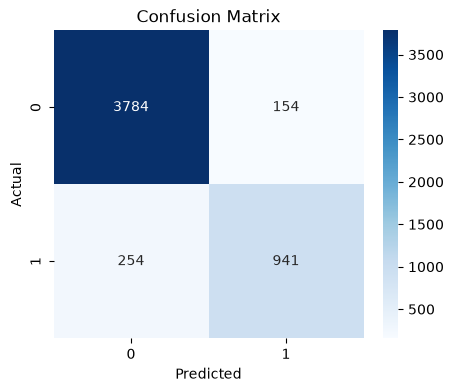

In [217]:
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') # fmt='d' -> decimal integers i.e., instead of 10.0 show 10
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance

<Figure size 800x600 with 0 Axes>

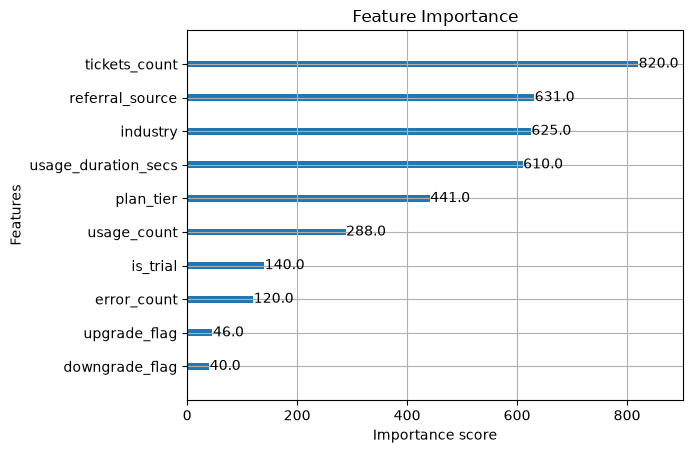

In [218]:
plt.figure(figsize=(8, 6))
xgb.plot_importance(model)
plt.title('Feature Importance')
plt.show()

# Export Model

In [219]:
model.save_model(f"{gbl_pth}\\churn_predictor\\exported_model\\xgb_churn_predictor.json")

metadata = {
    "feature_columns": list(X_train.columns),
    "categorical_columns": [
        "referral_source",
        "industry",
        "plan_tier"
    ],
    "categories": {
        col: X_train[col].cat.categories.tolist()
        for col in X_train.select_dtypes(include="category").columns
    }
}

with open(f"{gbl_pth}\\churn_predictor\\exported_model\\xgb_churn_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)